# EDA - Disque Denuncia (CompStat Rio)

The **Disque Denuncia** dataset is the qualitative arm of CompStat: each row is an
anonymous tip describing *modus operandi*, schedule, escape routes, and people
involved in suspected crimes. It complements the quantitative **ocorrencias** feed.

This notebook gives a first pass over the file shipped in `dados/disk_denuncia.csv`.

## Three gotchas before you load anything

1. **Separator is `;`** (semicolon), not comma. `pd.read_csv` will guess wrong otherwise.
2. **Encoding is `latin-1`**, not UTF-8. If you see `SUBST�NCIAS` instead of `SUBSTANCIAS ENTORPECENTES`, that's the wrong codec.
3. **Lat / Long use comma as decimal separator** (`-22,899555`). You need to replace `,` with `.` before casting to float.

Also: **one denuncia can occupy multiple rows** (one per orgao difundido), with empty
logradouro/lat/long on the trailing rows. Always dedupe by `id_denuncia` before counting.


In [1]:
import os, sys, warnings
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.environ.get('TMPDIR', '/tmp'), 'matplotlib'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

REPO = Path('../..').resolve()
DATA = REPO / 'dados' / 'disk_denuncia.csv'
FM_SHP = REPO / 'sh_area_forca' / 'areas_forca_municipal.shp'
print('Repo:', REPO)
print('Data exists:', DATA.exists(), '| FM shapefile exists:', FM_SHP.exists())


Repo: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio
Data exists: True | FM shapefile exists: True


## 2. Load and deduplicate

Read with the right separator + encoding, then collapse the one-row-per-orgao
expansion into one row per `id_denuncia`. For each tip we keep the first non-empty
value of every column.


In [2]:
raw = pd.read_csv(DATA, sep=';', encoding='latin-1', dtype=str)
print(f'Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} cols')

# Strip whitespace; treat empty strings as NaN
raw = raw.apply(lambda s: s.str.strip() if s.dtype == 'object' else s)
raw = raw.replace({'': np.nan})

# Dedupe by id_denuncia keeping first non-null per column
def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

df = raw.groupby('id_denuncia', as_index=False, sort=False).agg(first_non_null)
print(f'After dedup by id_denuncia: {df.shape[0]:,} rows')
print(f'Rows collapsed: {raw.shape[0] - df.shape[0]:,}')


Raw shape: 83,549 rows x 48 cols
After dedup by id_denuncia: 18,003 rows
Rows collapsed: 65,546


### Schema

In [3]:
schema = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'pct_filled': (df.notna().mean() * 100).round(1),
    'sample': [df[c].dropna().astype(str).head(1).values[0] if df[c].notna().any() else '' for c in df.columns],
})
schema.head(50)


Out[3]: 
                                     dtype  ...                                             sample
id_denuncia                            str  ...                                            2301680
numero_denuncia                        str  ...                                        1024.6.2020
data_denuncia                          str  ...                                   6/4/2020 8:16:00
data_difusao                           str  ...                                 6/15/2020 14:57:00
tipo_logradouro                        str  ...                                                  R
logradouro                             str  ...                                       SANTO CRISTO
numero_logradouro                      str  ...                                                240
complemento_logradouro                 str  ...                                             AP 303
bairro_logradouro                      str  ...                                       SANTO CRISTO
s

,dtype,non_null,pct_filled,sample
id_denuncia,str,18003,100.0,2301680
numero_denuncia,str,18003,100.0,1024.6.2020
data_denuncia,str,18003,100.0,6/4/2020 8:16:00
data_difusao,str,18003,100.0,6/15/2020 14:57:00
tipo_logradouro,str,17991,99.9,R
logradouro,str,18003,100.0,SANTO CRISTO
numero_logradouro,str,7038,39.1,240
complemento_logradouro,str,2470,13.7,AP 303
bairro_logradouro,str,18003,100.0,SANTO CRISTO
subbairro_logradouro,str,3817,21.2,0


### Type coercions

Parse `data_denuncia` (American-style `M/D/YYYY HH:MM:SS`), and convert
latitude/longitude from `-22,899555` to float.


In [4]:
df['data_denuncia'] = pd.to_datetime(df['data_denuncia'], errors='coerce', format='%m/%d/%Y %H:%M:%S')

for col in ('latitude', 'longitude'):
    df[col] = (
        df[col].astype(str)
              .str.replace(',', '.', regex=False)
              .replace({'nan': np.nan})
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('data_denuncia range:', df['data_denuncia'].min(), '->', df['data_denuncia'].max())
print('lat min/max:', df['latitude'].min(), df['latitude'].max())
print('long min/max:', df['longitude'].min(), df['longitude'].max())
print('rows with valid coords:', df[['latitude','longitude']].dropna().shape[0])


data_denuncia range: 2019-01-02 07:39:00 -> 2026-05-08 17:37:00
lat min/max: -23.0714198 -7.2860449
long min/max: -48.5103675 -34.8054584
rows with valid coords: 17850


## 3. Top classes and tipos

The columns `classe` / `tipo` give the taxonomy of what each tip is about.
Below: the 15 most frequent classes and the 20 most frequent tipos.


Top 5 classes:
classe
SUBSTÂNCIAS ENTORPECENTES     9233
CRIMES CONTRA O PATRIMÔNIO    8770


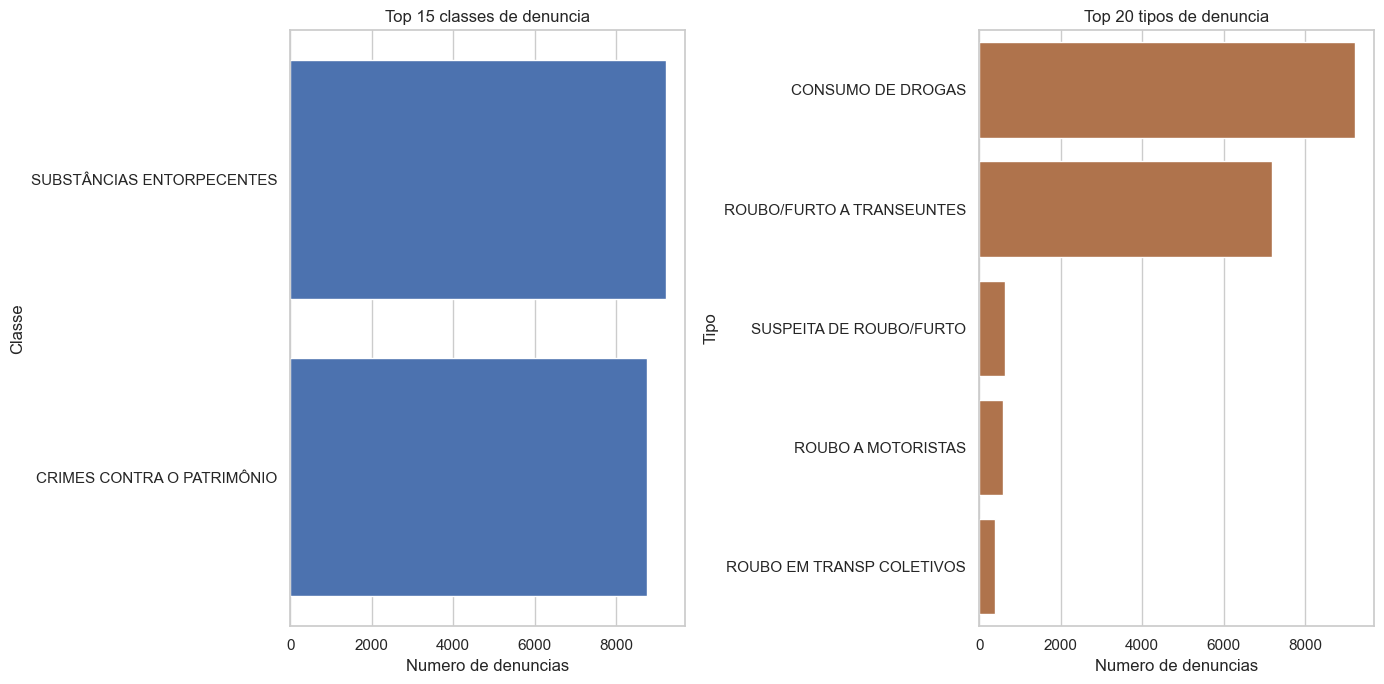

In [5]:
top_classes = df['classe'].value_counts().head(15)
top_tipos = df['tipo'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sns.barplot(x=top_classes.values, y=top_classes.index, ax=axes[0], color='#3b6fbf')
axes[0].set_title('Top 15 classes de denuncia')
axes[0].set_xlabel('Numero de denuncias')
axes[0].set_ylabel('Classe')

sns.barplot(x=top_tipos.values, y=top_tipos.index, ax=axes[1], color='#bf6f3b')
axes[1].set_title('Top 20 tipos de denuncia')
axes[1].set_xlabel('Numero de denuncias')
axes[1].set_ylabel('Tipo')

plt.tight_layout()
plt.show()

print('Top 5 classes:')
print(top_classes.head().to_string())


## 4. Top bairros and sub-bairros

Where in the city the tips concentrate. Note that the long tail is enormous - the top
20 bairros only cover a fraction of the total volume.


Top 20 bairros concentram 45.8% das denuncias com bairro preenchido.


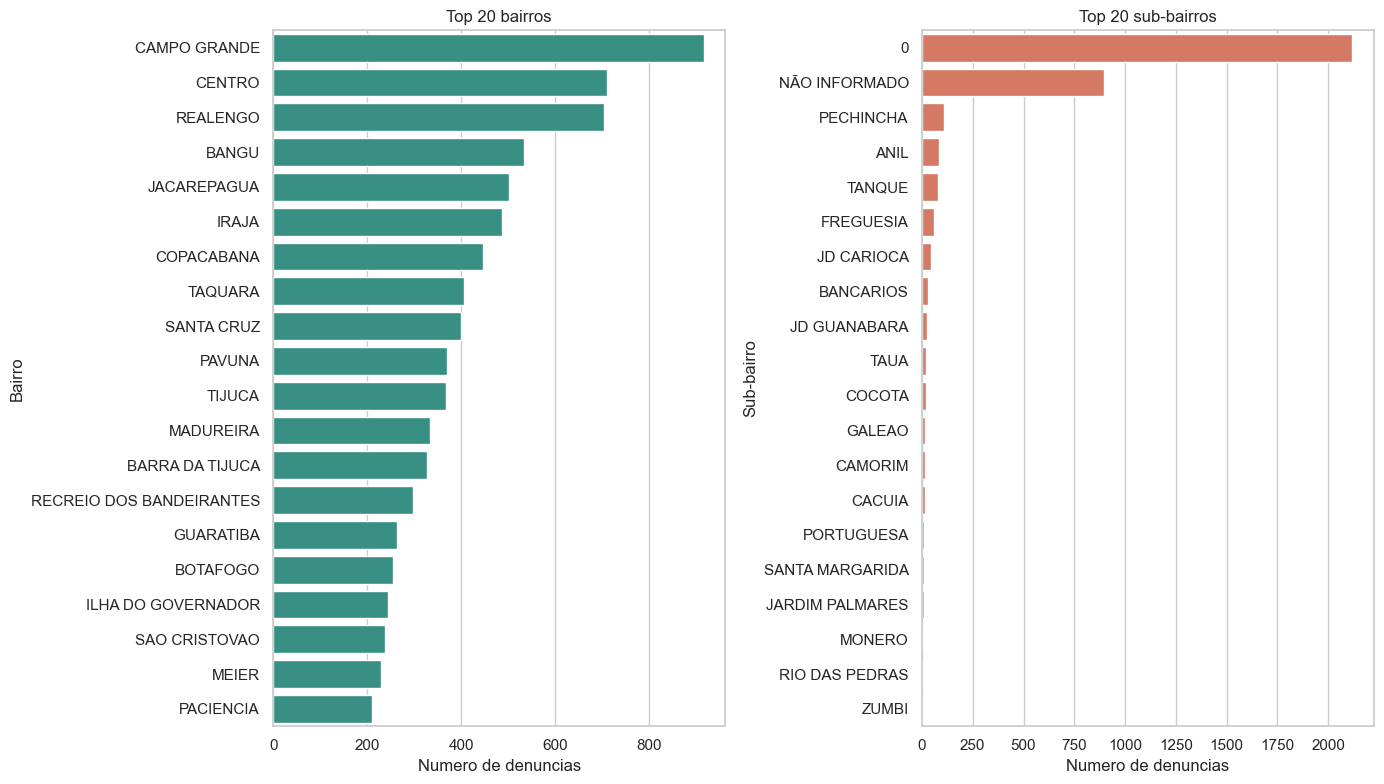

In [6]:
top_bairros = df['bairro_logradouro'].value_counts().head(20)
top_sub = df['subbairro_logradouro'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
sns.barplot(x=top_bairros.values, y=top_bairros.index, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Top 20 bairros')
axes[0].set_xlabel('Numero de denuncias')
axes[0].set_ylabel('Bairro')

sns.barplot(x=top_sub.values, y=top_sub.index, ax=axes[1], color='#e76f51')
axes[1].set_title('Top 20 sub-bairros')
axes[1].set_xlabel('Numero de denuncias')
axes[1].set_ylabel('Sub-bairro')

plt.tight_layout()
plt.show()

share_top20 = top_bairros.sum() / df['bairro_logradouro'].notna().sum() * 100
print(f'Top 20 bairros concentram {share_top20:.1f}% das denuncias com bairro preenchido.')


## 5. Temporal pattern - denuncias por mes

Monthly volume overall and for the top 5 classes. Useful for spotting bursts,
seasonal patterns or reporting changes.


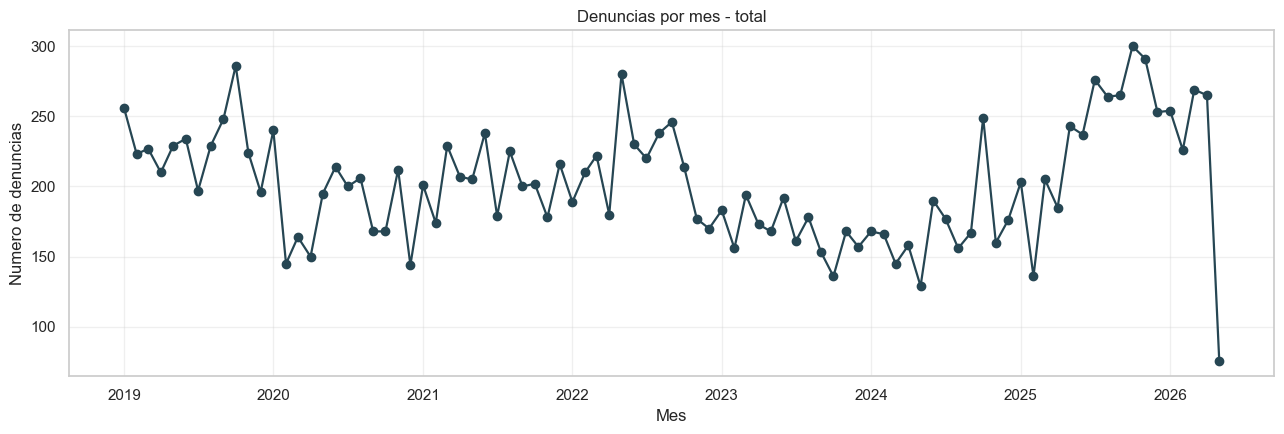

In [7]:
ts = df.dropna(subset=['data_denuncia']).copy()
ts['mes'] = ts['data_denuncia'].dt.to_period('M').dt.to_timestamp()

monthly = ts.groupby('mes').size()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(monthly.index, monthly.values, marker='o', linewidth=1.6, color='#264653')
ax.set_title('Denuncias por mes - total')
ax.set_xlabel('Mes')
ax.set_ylabel('Numero de denuncias')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


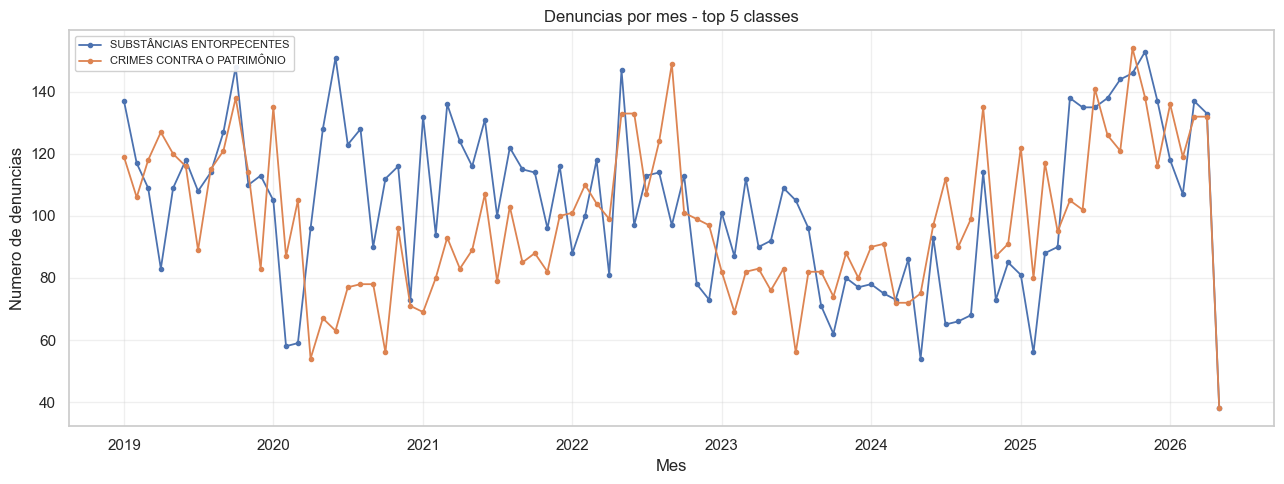

In [8]:
top5_classes = df['classe'].value_counts().head(5).index.tolist()
by_class = (
    ts[ts['classe'].isin(top5_classes)]
      .groupby(['mes', 'classe']).size().unstack(fill_value=0)
      .reindex(columns=top5_classes)
)

fig, ax = plt.subplots(figsize=(13, 5))
for col in by_class.columns:
    ax.plot(by_class.index, by_class[col], marker='.', linewidth=1.3, label=col)
ax.set_title('Denuncias por mes - top 5 classes')
ax.set_xlabel('Mes')
ax.set_ylabel('Numero de denuncias')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Distribuicao geografica

Scatter dos pontos com lat/long validos, restritos ao bounding-box do municipio do
Rio (`-43.8 < long < -43.1`, `-23.1 < lat < -22.7`). Polígonos verdes: as 8 areas
de Forca Municipal em escopo.


Pontos com coords validas no bbox do Rio: 17,784


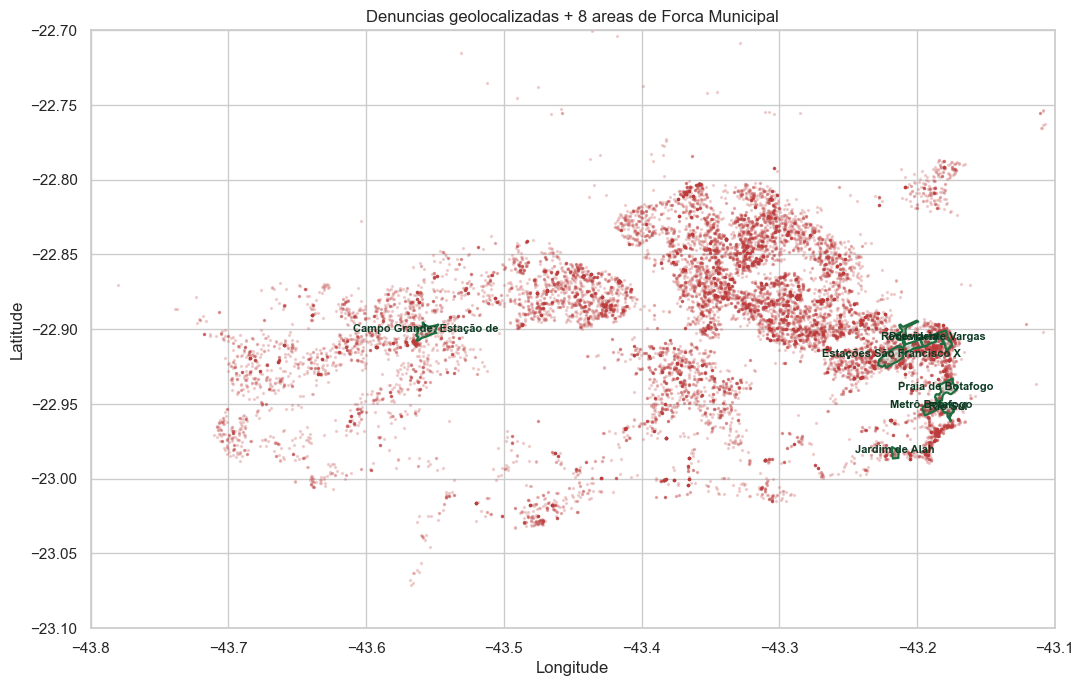

In [9]:
geo = df.dropna(subset=['latitude', 'longitude']).copy()
mask = (
    geo['longitude'].between(-43.8, -43.1)
    & geo['latitude'].between(-23.1, -22.7)
)
geo = geo.loc[mask].copy()
print(f'Pontos com coords validas no bbox do Rio: {len(geo):,}')

fm = gpd.read_file(FM_SHP).to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(11, 10))
ax.scatter(geo['longitude'], geo['latitude'], s=2, alpha=0.18, color='#bf3b3b', label='Denuncia')
fm.boundary.plot(ax=ax, color='#1d6f42', linewidth=1.6)
fm.plot(ax=ax, color='#1d6f42', alpha=0.18)
for _, r in fm.iterrows():
    c = r['geometry'].centroid
    label = r['nome_subar'].split(' - ')[0][:24]
    ax.annotate(label, (c.x, c.y), fontsize=8, ha='center', color='#0d3a23',
                fontweight='bold')
ax.set_title('Denuncias geolocalizadas + 8 areas de Forca Municipal')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_xlim(-43.8, -43.1); ax.set_ylim(-23.1, -22.7)
plt.tight_layout(); plt.show()


## 7. Denuncias por area de Forca Municipal

Spatial-join: para cada ponto, qual poligono de FM ele cai dentro (se algum).


Pontos dentro de alguma area FM: 772 de 17,784 (4.3%)


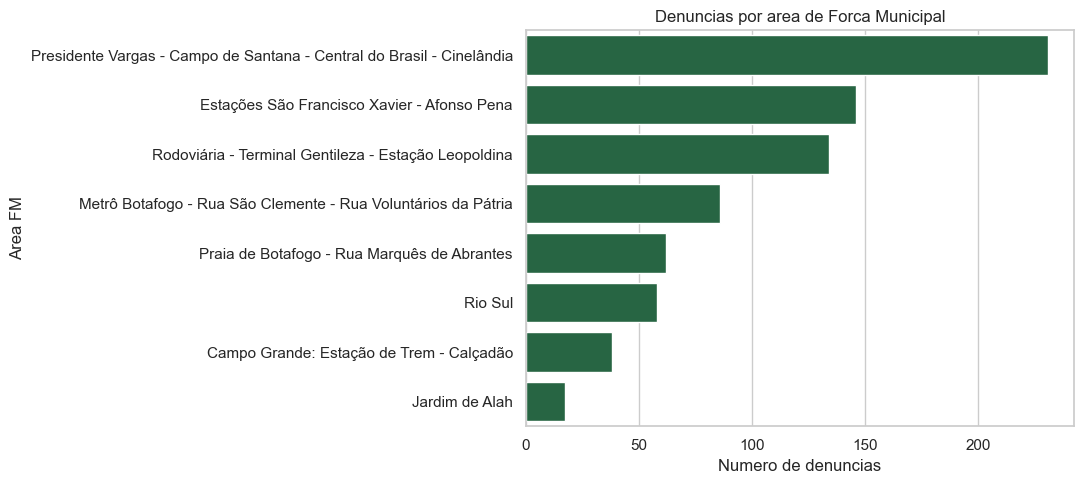

In [10]:
gpts = gpd.GeoDataFrame(
    geo, geometry=gpd.points_from_xy(geo['longitude'], geo['latitude']), crs='EPSG:4326'
)

joined = gpd.sjoin(gpts, fm[['nome_subar','geometry']], how='left', predicate='within')
in_fm = joined.dropna(subset=['nome_subar']).copy()
print(f'Pontos dentro de alguma area FM: {len(in_fm):,} de {len(gpts):,} ({len(in_fm)/len(gpts)*100:.1f}%)')

per_area = in_fm['nome_subar'].value_counts()
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=per_area.values, y=per_area.index, color='#1d6f42', ax=ax)
ax.set_title('Denuncias por area de Forca Municipal')
ax.set_xlabel('Numero de denuncias')
ax.set_ylabel('Area FM')
plt.tight_layout(); plt.show()


### Top 5 classes em cada area FM

In [11]:
top_per_area = (
    in_fm.groupby(['nome_subar','classe']).size()
         .rename('n')
         .reset_index()
         .sort_values(['nome_subar','n'], ascending=[True, False])
)
top_per_area['nome_curto'] = top_per_area['nome_subar'].str.split(' - ').str[0].str[:30]

frames = []
for area, g in top_per_area.groupby('nome_subar'):
    frames.append(g.head(5))
display_df = pd.concat(frames)[['nome_curto','classe','n']].reset_index(drop=True)
display_df


Out[11]: 
                       nome_curto                      classe    n
0   Campo Grande: Estação de Trem   SUBSTÂNCIAS ENTORPECENTES   20
1   Campo Grande: Estação de Trem  CRIMES CONTRA O PATRIMÔNIO   18
2   Estações São Francisco Xavier  CRIMES CONTRA O PATRIMÔNIO   76
3   Estações São Francisco Xavier   SUBSTÂNCIAS ENTORPECENTES   70
4                  Jardim de Alah   SUBSTÂNCIAS ENTORPECENTES   11
5                  Jardim de Alah  CRIMES CONTRA O PATRIMÔNIO    6
6                  Metrô Botafogo   SUBSTÂNCIAS ENTORPECENTES   52
7                  Metrô Botafogo  CRIMES CONTRA O PATRIMÔNIO   34
8               Praia de Botafogo  CRIMES CONTRA O PATRIMÔNIO   41
9               Praia de Botafogo   SUBSTÂNCIAS ENTORPECENTES   21
10              Presidente Vargas  CRIMES CONTRA O PATRIMÔNIO  157
11              Presidente Vargas   SUBSTÂNCIAS ENTORPECENTES   74
12                        Rio Sul  CRIMES CONTRA O PATRIMÔNIO   30
13                        Rio Sul   SUBSTÂNCIAS ENTO

,nome_curto,classe,n
0,Campo Grande: Estação de Trem,SUBSTÂNCIAS ENTORPECENTES,20
1,Campo Grande: Estação de Trem,CRIMES CONTRA O PATRIMÔNIO,18
2,Estações São Francisco Xavier,CRIMES CONTRA O PATRIMÔNIO,76
3,Estações São Francisco Xavier,SUBSTÂNCIAS ENTORPECENTES,70
4,Jardim de Alah,SUBSTÂNCIAS ENTORPECENTES,11
5,Jardim de Alah,CRIMES CONTRA O PATRIMÔNIO,6
6,Metrô Botafogo,SUBSTÂNCIAS ENTORPECENTES,52
7,Metrô Botafogo,CRIMES CONTRA O PATRIMÔNIO,34
8,Praia de Botafogo,CRIMES CONTRA O PATRIMÔNIO,41
9,Praia de Botafogo,SUBSTÂNCIAS ENTORPECENTES,21


## 8. Amostra de relatos - Crimes contra o Patrimonio

A textura qualitativa: 5 tips redigidos, com PII substituido por `[NOME]`.


In [12]:
patrim = df[df['classe'].str.contains('PATRIM', na=False, case=False)]
print(f'Denuncias na classe Crimes contra o Patrimonio: {len(patrim):,}')

sample = patrim['relato_redacted'].dropna().sample(5, random_state=42)
for i, txt in enumerate(sample, 1):
    txt = (txt or '').strip()
    if len(txt) > 600:
        txt = txt[:600] + '...'
    print(f'--- Relato {i} ---')
    print(txt)
    print()


Denuncias na classe Crimes contra o Patrimonio: 8,770
--- Relato 1 ---
NO BAIRRO MENCIONADO LOCALIZAMSE AS PASSARELAS DA ESTACAO DA SUPERVIA ONDE FREQUENTEMENTE INDIVIDUOS NAO IDENTIFICADOS PROMOVEM ASSALTOS A TRANSEUNTES ISSO TAMBEM OCORRE NAS PASSARELAS DA SUPERVIA DO BAIRRO HONORIO GURGEL

--- Relato 2 ---
NO ENDERECO CITADO LOCALIZASE UM CONJUNTO RESIDENCIAL ONDE AO REDOR DA QUADRA E PROXIMO A UM BAR MENORES INFRATORES NAO IDENTIFICADOS RELACIONADOS COM O TRAFICO DE DROGAS ORIUNDOS DAS COMUNIDADES DO PARAPEDRO E DO [NOME] PERMANECEM CIRCULANDO COM MOTOS PLACAS IGNORADAS E ASSALTANDO ENTREGADORES

--- Relato 3 ---
NA AVENIDA CITADA NO POSTO TRES PODEM SER VISTOS VARIOS INDIVIDUOS NAO IDENTIFICADOS QUE REALIZAM ASSALTOS A TURISTAS NO DOMINGO DIA 1712021 POR VOLTA DAS 20H OCORREU O ESPANCAMENTO DE UM TURISTA OS MESMOS FICAM SENTADOS E AGUARDAM OS TRANSEUNTES PASSAREM EM SUA MAIORIA TURISTAS MULHERES E IDOSOS PARA ATACAREM

--- Relato 4 ---
NA RUA MENCIONADA ESQUINA COM A RUA IRAPUA TR

## 9. Conclusoes

1. **A base e bagunca - mas previsivelmente bagunca.** Tres armadilhas grandes
   (separador `;`, encoding `latin-1`, virgula decimal nas coordenadas) e a expansao
   por orgao difundido que cria multiplas linhas por denuncia. Sem o dedup por
   `id_denuncia`, qualquer contagem fica inflada.

2. **Concentracao tematica clara.** Substancias entorpecentes e crimes contra o
   patrimonio dominam ~22% do volume, e a cauda de classes e curta. Isso facilita
   priorizar quais classes alimentar nos modelos quantitativos.

3. **Geografia consistente com a hipotese de CompStat.** As areas de Forca
   Municipal capturam uma fatia visivel dos pontos geocodificados; bairros tipo
   Campo Grande, Centro e Realengo aparecem tanto no ranking textual quanto na
   sobreposicao espacial - sinal de que `bairro_logradouro` e lat/long sao
   parcialmente redundantes mas se reforcam.

4. **Texto livre e o ativo real.** `relato_redacted` traz horario, modus operandi
   e rotas de fuga em portugues natural. E ai que mora o sinal qualitativo para
   priorizacao operacional - dificilmente capturavel via `ocorrencias` agregadas.

5. **Cobertura geografica e o gargalo.** Boa parte das denuncias nao tem
   lat/long no bbox do Rio (campo vazio, coordenadas zeradas ou fora do
   municipio). Para analises espaciais finas vale usar `bairro_logradouro` como
   fallback ou geocodificar logradouros.
